# Mini Project: Flight Price Prediction
This notebook builds an end-to-end **regression pipeline** to predict flight prices using `Clean_Dataset.csv`.

> Workflow: data audit → preprocessing → model comparison → diagnostics → save best pipeline.

In [47]:
# 1) Imports and settings
from __future__ import annotations

from pathlib import Path
from time import perf_counter
import hashlib
import importlib
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import BaggingRegressor, GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import auc, mean_absolute_error, mean_squared_error, r2_score, roc_curve
from sklearn.model_selection import KFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor

RANDOM_STATE = 42
TEST_SIZE = 0.2
# Supposed to be 80000 / 300000
CV_FOLDS = 3           # Set to 0 or 1 to skip cross-validation
MAX_ROWS = 2000        # Reduce this if runtime is high
USE_LOG_TARGET = False
USE_CACHE = True

DATA_PATH = Path('datasets/miniproject/Clean_Dataset.csv')
OUTPUT_DIR = Path('outputs/flight_price')
CACHE_DIR = OUTPUT_DIR / 'model_cache'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option('display.max_columns', 200)
sns.set_theme(style='whitegrid')

## 2) Load and inspect dataset

In [48]:
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
display(df.head())

print('\nData types:')
display(df.dtypes.to_frame('dtype').T)

print('\nMissing values per column:')
display(df.isna().sum().to_frame('missing_count').T)

print('\nDuplicate rows:', df.duplicated().sum())

Shape: (300153, 12)


,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955



Data types:


,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
dtype,int64,object,object,object,object,object,object,object,object,float64,int64,int64



Missing values per column:


,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
missing_count,0,0,0,0,0,0,0,0,0,0,0,0



Duplicate rows: 0


## 3) Preprocessing and feature setup

In [49]:
def load_and_prepare_data(df_in: pd.DataFrame) -> tuple[pd.DataFrame, pd.Series]:
    df_local = df_in.copy()

    if MAX_ROWS is not None and len(df_local) > MAX_ROWS:
        df_local = df_local.sample(n=MAX_ROWS, random_state=RANDOM_STATE)

    unnamed_cols = [c for c in df_local.columns if c.lower().startswith('unnamed')]
    if unnamed_cols:
        df_local = df_local.drop(columns=unnamed_cols)

    if 'stops' in df_local.columns:
        stop_map = {'zero': 0, 'one': 1, 'two_or_more': 2}
        mapped_stops = df_local['stops'].map(stop_map)
        if mapped_stops.notna().all():
            df_local['stops'] = mapped_stops.astype(int)

    if 'price' not in df_local.columns:
        raise ValueError("Dataset must contain a 'price' column")

    y_local = df_local['price'].astype(float)
    X_local = df_local.drop(columns=['price'])

    constant_cols = [c for c in X_local.columns if X_local[c].nunique(dropna=False) <= 1]
    if constant_cols:
        X_local = X_local.drop(columns=constant_cols)
        print('Dropped constant columns:', constant_cols)

    return X_local, y_local


def build_preprocessor(X_local: pd.DataFrame) -> ColumnTransformer:
    categorical_cols = X_local.select_dtypes(include=['object', 'category']).columns.tolist()
    numeric_cols = [c for c in X_local.columns if c not in categorical_cols]

    numeric_transformer = Pipeline(
        steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
        ]
    )

    categorical_transformer = Pipeline(
        steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore')),
        ]
    )

    preprocessor_local = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_cols),
            ('cat', categorical_transformer, categorical_cols),
        ]
    )
    return preprocessor_local


def build_models() -> dict[str, object]:
    models_local: dict[str, object] = {
        'dummy_mean': DummyRegressor(strategy='mean'),
        'ridge': Ridge(alpha=1.0),
        'linear_regression': LinearRegression(),
        'lasso': Lasso(alpha=0.001, max_iter=10_000),
        'decision_tree': DecisionTreeRegressor(
            random_state=RANDOM_STATE,
            max_depth=10,
            min_samples_leaf=5,
        ),
        'bagging': BaggingRegressor(
            estimator=DecisionTreeRegressor(
                random_state=RANDOM_STATE,
                max_depth=10,
                min_samples_leaf=5,
            ),
            n_estimators=60,
            max_samples=0.7,
            bootstrap=True,
            n_jobs=-1,
            random_state=RANDOM_STATE,
        ),
        'random_forest': RandomForestRegressor(
            n_estimators=120,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        'gradient_boosting': GradientBoostingRegressor(random_state=RANDOM_STATE),
    }

    try:
        xgboost_module = importlib.import_module('xgboost')
        xgb_regressor = getattr(xgboost_module, 'XGBRegressor')
        models_local['xgboost'] = xgb_regressor(
            n_estimators=180,
            learning_rate=0.05,
            max_depth=5,
            subsample=0.9,
            colsample_bytree=0.9,
            random_state=RANDOM_STATE,
            objective='reg:squarederror',
            n_jobs=-1,
        )
    except ImportError:
        pass

    try:
        lightgbm_module = importlib.import_module('lightgbm')
        lgbm_regressor = getattr(lightgbm_module, 'LGBMRegressor')
        models_local['lightgbm'] = lgbm_regressor(
            n_estimators=200,
            learning_rate=0.05,
            random_state=RANDOM_STATE,
        )
    except ImportError:
        pass

    return models_local

## 4) Train-test split and model evaluation

In [50]:
X, y = load_and_prepare_data(df)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

preprocessor = build_preprocessor(X)
models = build_models()

print(f'Train shape: {X_train.shape}, Test shape: {X_test.shape}')
print('Models:', list(models.keys()))

rows = []
best_rmse = float('inf')
best_model_name = None
best_pipeline = None
trained_pipelines = {}

scoring = {
    'rmse': 'neg_root_mean_squared_error',
    'mae': 'neg_mean_absolute_error',
    'r2': 'r2',
}

y_train_fit = np.log1p(y_train) if USE_LOG_TARGET else y_train
total_models = len(models)

# Build cache namespace from dataset metadata + run configuration.
resolved_data_path = DATA_PATH.resolve()
data_stat = resolved_data_path.stat()
cache_payload = {
    'data_path': str(resolved_data_path),
    'data_mtime_ns': data_stat.st_mtime_ns,
    'data_size': data_stat.st_size,
    'random_state': RANDOM_STATE,
    'test_size': TEST_SIZE,
    'use_log_target': USE_LOG_TARGET,
    'max_rows': MAX_ROWS,
    'cv_folds': CV_FOLDS,
    'n_train': int(len(X_train)),
    'n_test': int(len(X_test)),
    'columns': X_train.columns.tolist(),
    'models': sorted(models.keys()),
}
cache_namespace = hashlib.sha256(
    json.dumps(cache_payload, sort_keys=True, separators=(',', ':')).encode('utf-8')
).hexdigest()[:16]

joblib_module = None
if USE_CACHE:
    CACHE_DIR.mkdir(parents=True, exist_ok=True)
    try:
        joblib_module = importlib.import_module('joblib')
    except ImportError:
        print('joblib not installed; proceeding without model cache.')

for idx, (model_name, estimator) in enumerate(models.items(), start=1):
    model_start = perf_counter()
    cache_path = CACHE_DIR / f'{model_name}__{cache_namespace}.joblib'

    if USE_CACHE and joblib_module is not None and cache_path.exists():
        print(f'[{idx}/{total_models}] Loading cached model: {model_name}')
        cached = joblib_module.load(cache_path)
        pipe = cached['pipeline']
        cv_rmse_mean = float(cached['cv_rmse_mean'])
        cv_rmse_std = float(cached['cv_rmse_std'])
        cv_mae_mean = float(cached['cv_mae_mean'])
        cv_r2_mean = float(cached['cv_r2_mean'])
        test_rmse = float(cached['test_rmse'])
        test_mae = float(cached['test_mae'])
        test_r2 = float(cached['test_r2'])
    else:
        print(f'[{idx}/{total_models}] Training model: {model_name}')

        pipe = Pipeline(
            steps=[
                ('preprocessor', preprocessor),
                ('model', estimator),
            ]
        )

        if CV_FOLDS >= 2:
            cv = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
            cv_results = cross_validate(
                pipe, X_train, y_train_fit, cv=cv, scoring=scoring, n_jobs=1
            )
            cv_rmse_mean = float(-cv_results['test_rmse'].mean())
            cv_rmse_std = float(cv_results['test_rmse'].std())
            cv_mae_mean = float(-cv_results['test_mae'].mean())
            cv_r2_mean = float(cv_results['test_r2'].mean())
        else:
            cv_rmse_mean = np.nan
            cv_rmse_std = np.nan
            cv_mae_mean = np.nan
            cv_r2_mean = np.nan

        pipe.fit(X_train, y_train_fit)
        pred_test = pipe.predict(X_test)
        if USE_LOG_TARGET:
            pred_test = np.expm1(pred_test)

        test_rmse = float(np.sqrt(mean_squared_error(y_test, pred_test)))
        test_mae = float(mean_absolute_error(y_test, pred_test))
        test_r2 = float(r2_score(y_test, pred_test))

        if USE_CACHE and joblib_module is not None:
            to_cache = {
                'pipeline': pipe,
                'cv_rmse_mean': cv_rmse_mean,
                'cv_rmse_std': cv_rmse_std,
                'cv_mae_mean': cv_mae_mean,
                'cv_r2_mean': cv_r2_mean,
                'test_rmse': test_rmse,
                'test_mae': test_mae,
                'test_r2': test_r2,
            }
            joblib_module.dump(to_cache, cache_path)

    trained_pipelines[model_name] = pipe

    rows.append({
        'model': model_name,
        'cv_rmse_mean': cv_rmse_mean,
        'cv_rmse_std': cv_rmse_std,
        'cv_mae_mean': cv_mae_mean,
        'cv_r2_mean': cv_r2_mean,
        'test_rmse': test_rmse,
        'test_mae': test_mae,
        'test_r2': test_r2,
    })

    if test_rmse < best_rmse:
        best_rmse = test_rmse
        best_model_name = model_name
        best_pipeline = pipe

    elapsed = perf_counter() - model_start
    print(
        f'    Done {model_name} in {elapsed:.2f}s | '
        f'test_rmse={test_rmse:.4f}, test_r2={test_r2:.4f}'
    )

results = pd.DataFrame(rows).sort_values('test_rmse').reset_index(drop=True)
display(results.round(4))
print('Best model:', best_model_name)

Train shape: (1600, 10), Test shape: (400, 10)
Models: ['dummy_mean', 'ridge', 'linear_regression', 'lasso', 'decision_tree', 'bagging', 'random_forest', 'gradient_boosting', 'xgboost', 'lightgbm']
[1/10] Loading cached model: dummy_mean
    Done dummy_mean in 0.00s | test_rmse=22680.3666, test_r2=-0.0010
[2/10] Loading cached model: ridge
    Done ridge in 0.00s | test_rmse=6471.5088, test_r2=0.9185
[3/10] Loading cached model: linear_regression
    Done linear_regression in 0.00s | test_rmse=10365.0099, test_r2=0.7909
[4/10] Loading cached model: lasso
    Done lasso in 0.00s | test_rmse=9849.5653, test_r2=0.8112
[5/10] Loading cached model: decision_tree
    Done decision_tree in 0.00s | test_rmse=5707.2850, test_r2=0.9366
[6/10] Loading cached model: bagging
    Done bagging in 0.01s | test_rmse=5425.6123, test_r2=0.9427
[7/10] Loading cached model: random_forest
    Done random_forest in 0.01s | test_rmse=4885.6863, test_r2=0.9536
[8/10] Loading cached model: gradient_boosting
   

,model,cv_rmse_mean,cv_rmse_std,cv_mae_mean,cv_r2_mean,test_rmse,test_mae,test_r2
0,random_forest,4895.1245,18.0252,2806.8608,0.9534,4885.6863,2597.6964,0.9536
1,xgboost,4955.9191,120.1206,2924.5933,0.9523,5038.5364,2907.6866,0.9506
2,gradient_boosting,5161.8041,197.5697,3079.9922,0.9481,5401.0506,3142.6860,0.9432
3,lightgbm,5187.8139,300.5007,3095.4689,0.9477,5402.2167,3075.3524,0.9432
4,bagging,5130.9080,162.2286,3039.5995,0.9489,5425.6123,3005.0036,0.9427
5,decision_tree,5453.5159,31.6868,3306.1519,0.9422,5707.2850,3318.2002,0.9366
6,ridge,6984.0965,386.6766,4782.9464,0.9051,6471.5088,4486.3578,0.9185
7,lasso,8637.8236,972.3351,6220.6381,0.8526,9849.5653,6971.6451,0.8112
8,linear_regression,8637.4314,989.1115,6228.0028,0.8526,10365.0099,7254.0860,0.7909
9,dummy_mean,22713.9812,556.4029,19598.5532,-0.0020,22680.3666,19620.6266,-0.0010


Best model: random_forest


## 5) Diagnostics: predictions and residuals

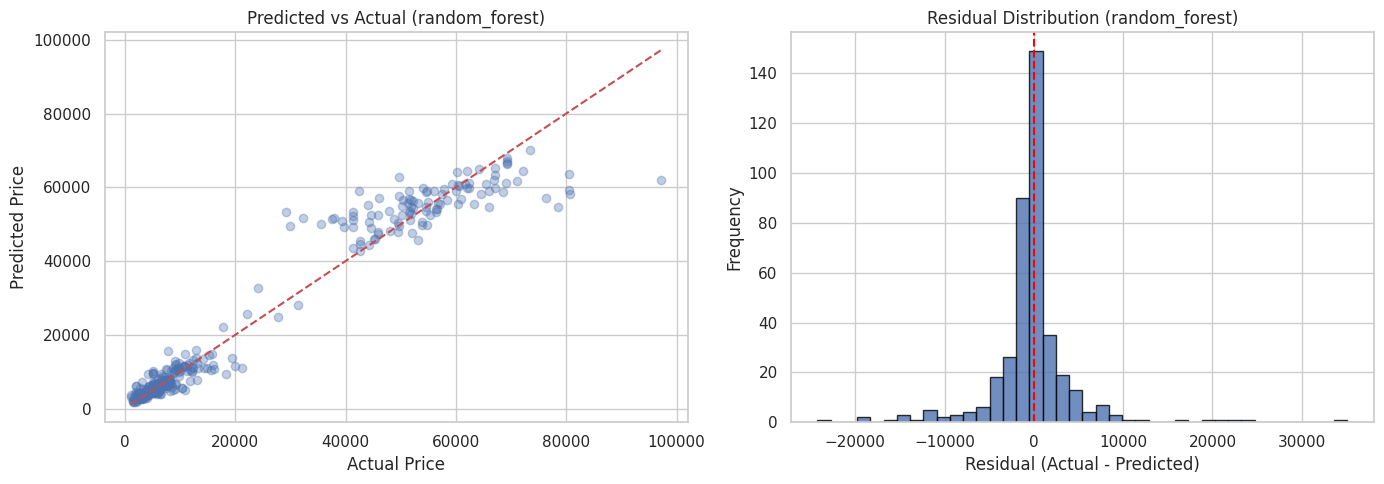

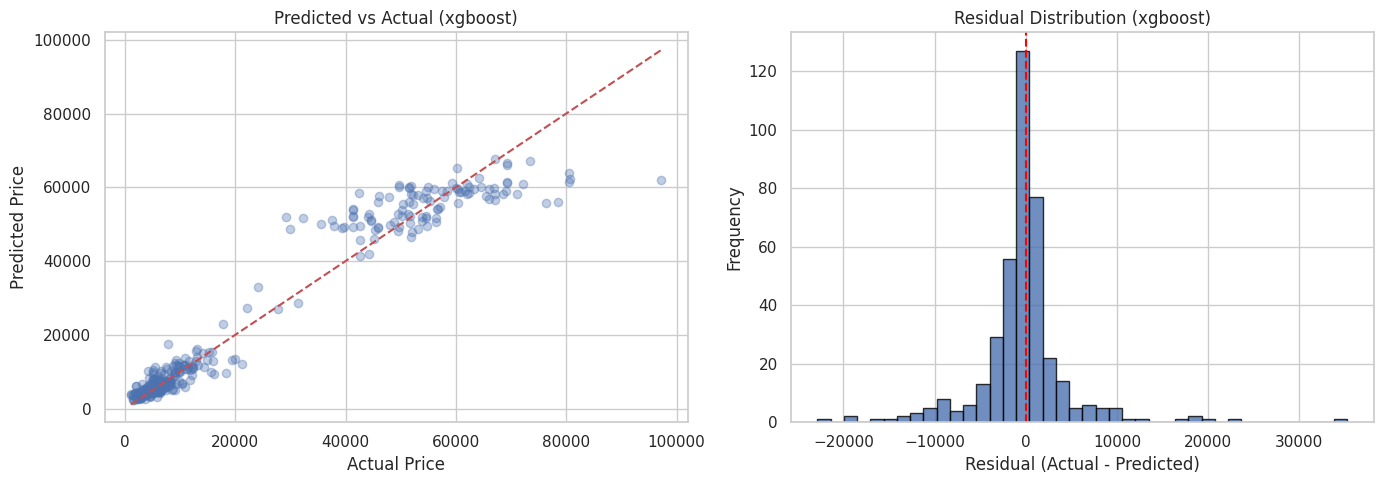

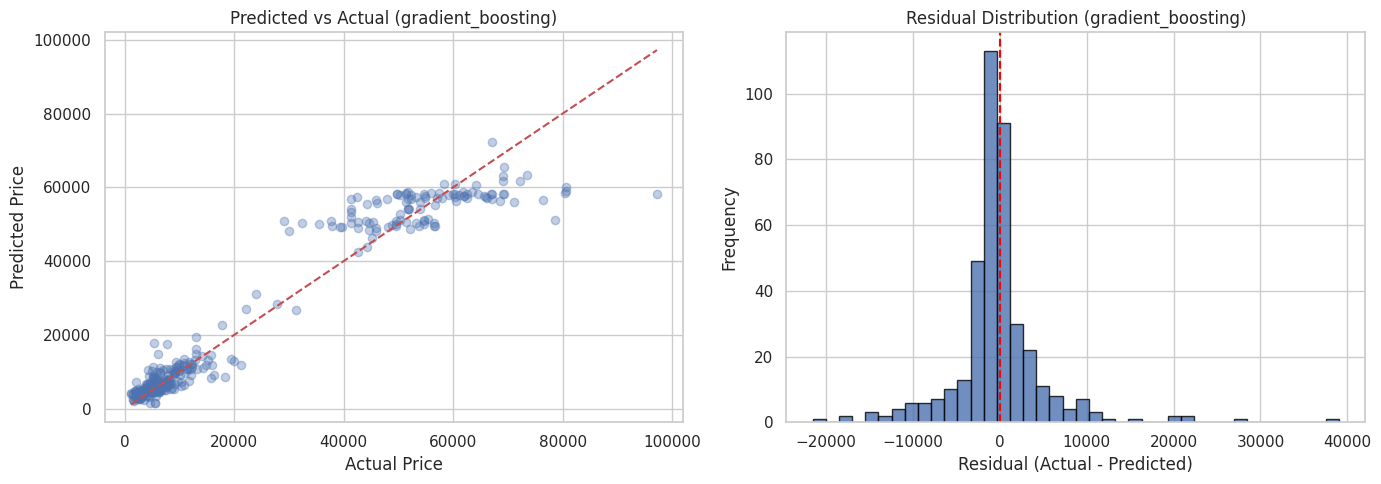

/home/ibu/Documents/collegework/sem6/mll/.venv/lib64/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


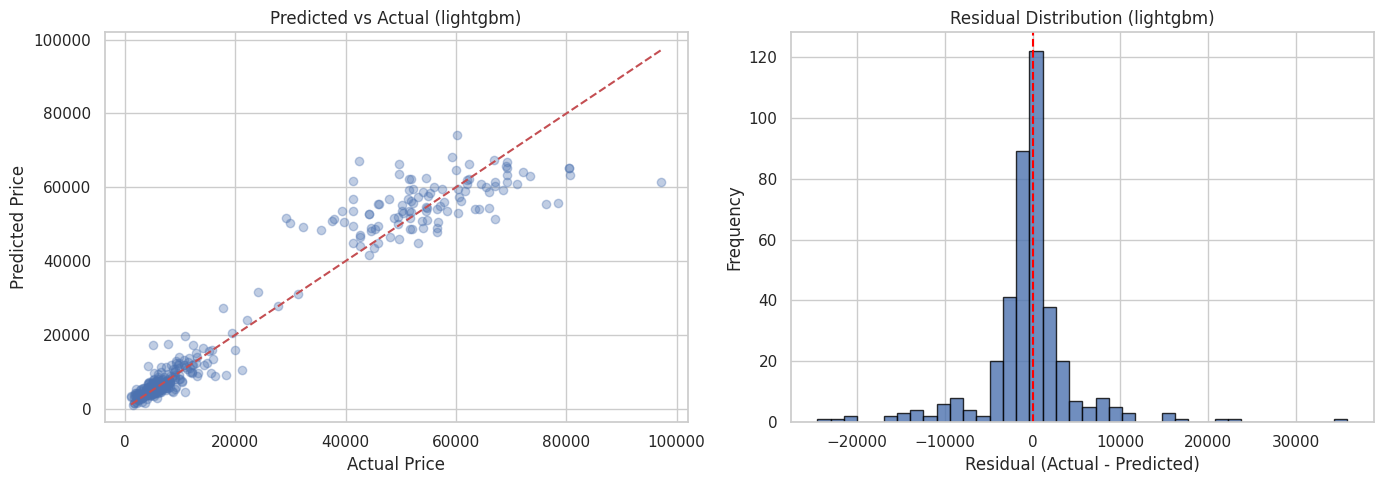

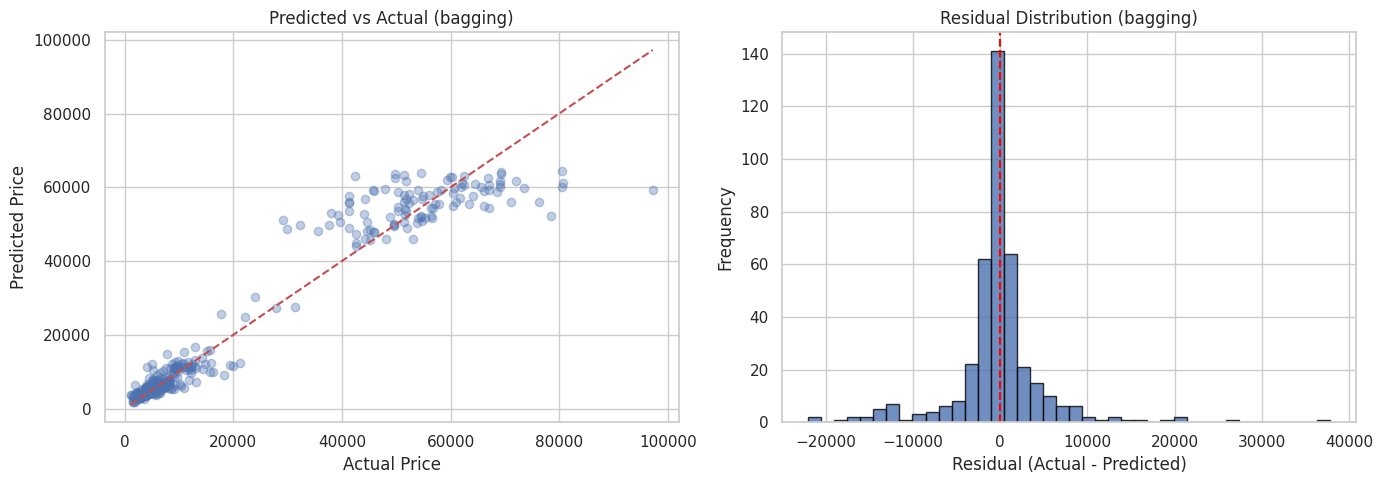

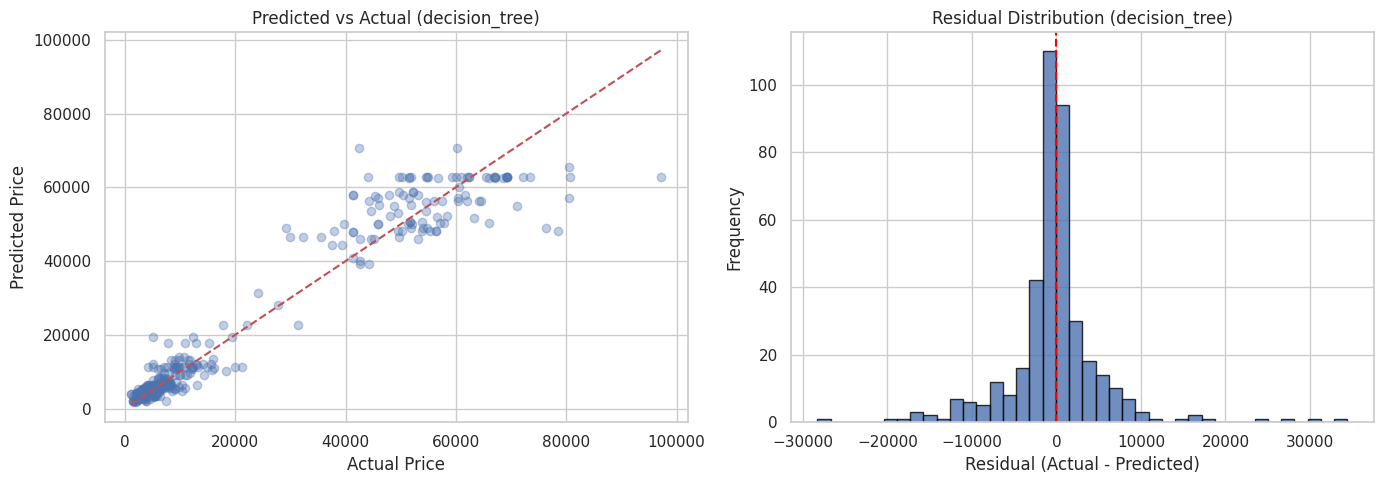

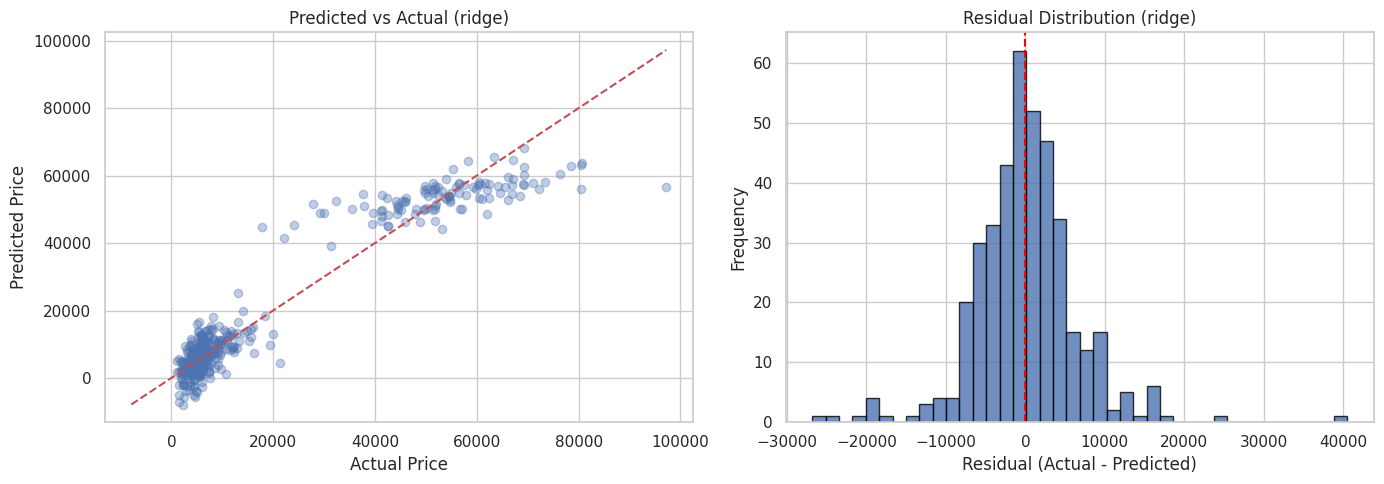

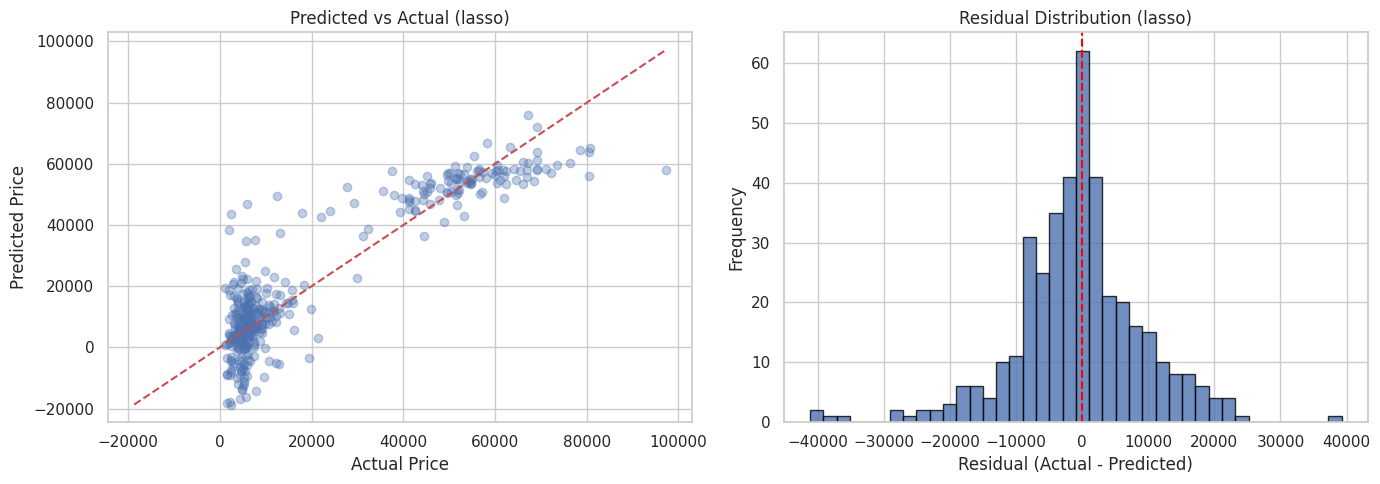

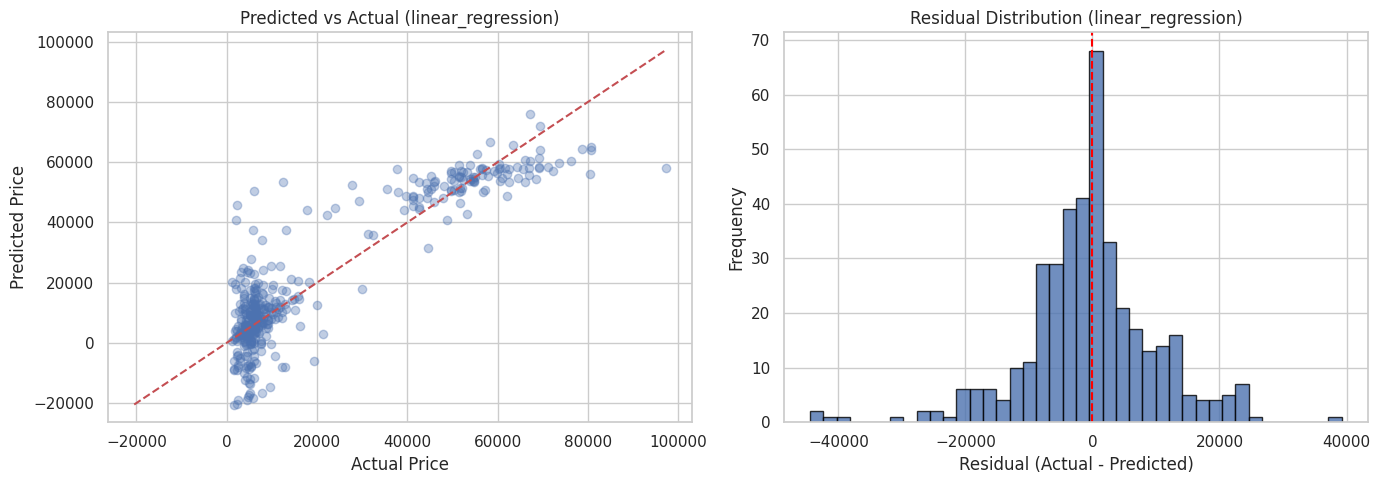

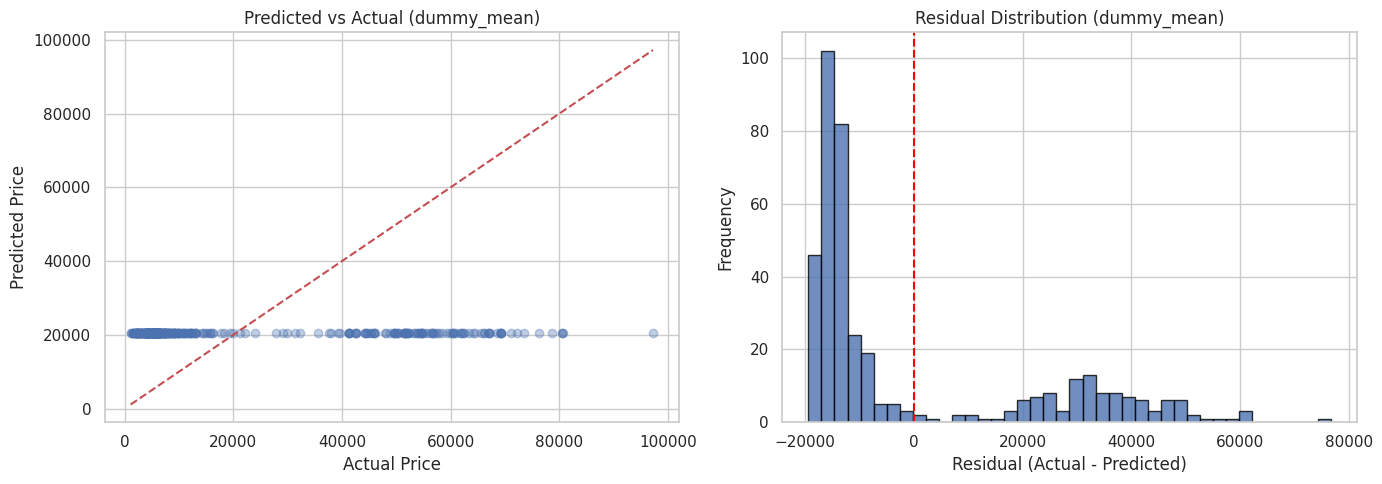

In [51]:
if not trained_pipelines:
    raise RuntimeError('No trained pipelines available. Run the training cell first.')

for model_name in results['model'].tolist():
    pipe = trained_pipelines[model_name]
    y_pred_model = pipe.predict(X_test)
    if USE_LOG_TARGET:
        y_pred_model = np.expm1(y_pred_model)

    residuals_model = y_test - y_pred_model

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].scatter(y_test, y_pred_model, alpha=0.35)
    min_v = min(float(y_test.min()), float(y_pred_model.min()))
    max_v = max(float(y_test.max()), float(y_pred_model.max()))
    axes[0].plot([min_v, max_v], [min_v, max_v], 'r--')
    axes[0].set_title(f'Predicted vs Actual ({model_name})')
    axes[0].set_xlabel('Actual Price')
    axes[0].set_ylabel('Predicted Price')

    axes[1].hist(residuals_model, bins=40, edgecolor='black', alpha=0.8)
    axes[1].axvline(0, color='red', linestyle='--')
    axes[1].set_title(f'Residual Distribution ({model_name})')
    axes[1].set_xlabel('Residual (Actual - Predicted)')
    axes[1].set_ylabel('Frequency')

    plt.tight_layout()
    plt.show()

# Keep best-model prediction variables for downstream cells (e.g., ROC-AUC).
y_pred = trained_pipelines[best_model_name].predict(X_test)
if USE_LOG_TARGET:
    y_pred = np.expm1(y_pred)
residuals = y_test - y_pred

## 6) ROC-AUC view (optional business framing)
ROC-AUC is a **classification** metric, not a native regression metric.

To include it meaningfully here, we convert the regression target into a binary label:
- `1` = high-price flight (`price >= median(train_price)`)
- `0` = low-price flight

> We then use predicted price as the ranking score for the ROC curve.

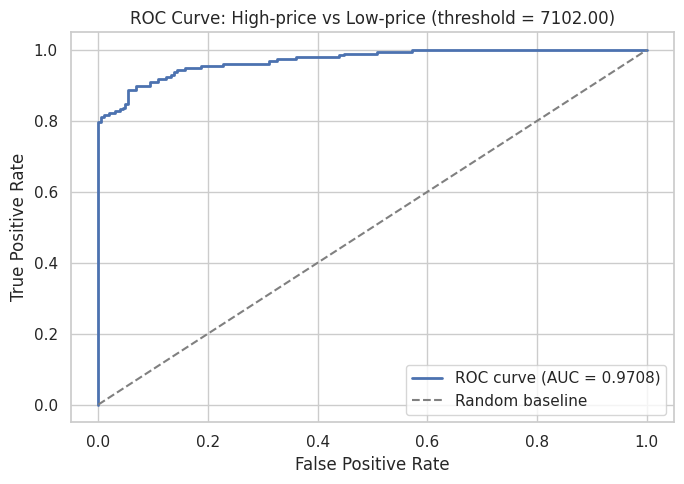

ROC-AUC (high-price classification view): 0.9708


In [52]:
# Convert regression target to binary classes using train median threshold
threshold = float(y_train.median())
y_test_binary = (y_test >= threshold).astype(int)

# Predicted price works as a continuous score for ranking high-price flights
y_score = y_pred

fpr, tpr, _ = roc_curve(y_test_binary, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve: High-price vs Low-price (threshold = {threshold:.2f})')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f'ROC-AUC (high-price classification view): {roc_auc:.4f}')

## 6) Save results and best model pipeline

In [53]:
results_path = OUTPUT_DIR / 'model_comparison.csv'
results.to_csv(results_path, index=False)

with (OUTPUT_DIR / 'best_model.txt').open('w', encoding='utf-8') as f:
    f.write(str(best_model_name))

try:
    import joblib
    joblib.dump(best_pipeline, OUTPUT_DIR / 'best_model_pipeline.joblib')
    print('Saved: best_model_pipeline.joblib')
except ImportError:
    print('joblib not installed; skipped pipeline serialization.')

print(f'Saved: {results_path}')
print(f'Saved: {OUTPUT_DIR / "best_model.txt"}')

Saved: best_model_pipeline.joblib
Saved: outputs/flight_price/model_comparison.csv
Saved: outputs/flight_price/best_model.txt


## 7) Conclusion (write-up template)
- Best performing model: **`best_model_name`** (from the table above).
- Report these metrics in your submission: **Test RMSE, Test MAE, Test R²**.
- Add 2–3 observations from the residual plot (bias, spread, outliers).
- Mention one limitation (no external demand/seasonality features) and one improvement (hyperparameter tuning on top models).